# Importing Modules

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, make_scorer, roc_curve
from sklearn.model_selection import GridSearchCV


# Data Preprocessing

In [3]:
# reading dataset from the csv file
customer_data = pd.read_csv("BankChurners.csv")

customer_data


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


In [4]:
# Mapping Attrition_Flag to desired values
# 'Existing Customer' => 0, 'Attrited Customer' => 1
customer_data['Attrition_Flag'] = customer_data['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

# Dropping CLIENTNUM if it is a unique identifier
columns_to_drop = ['CLIENTNUM',
                   'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                   'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
customer_data = customer_data.drop(columns=columns_to_drop)

# Encoding remaining categorical variables
categorical_columns = customer_data.select_dtypes(include=['object']).columns
customer_data = pd.get_dummies(customer_data, columns=categorical_columns, drop_first=True)

# Separating features and target
X = customer_data.drop(columns=['Attrition_Flag']) # features in x
y = customer_data['Attrition_Flag'] # target variable in y

customer_data

,Attrition_Flag,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,...,Marital_Status_Single,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,0,45,3,39,5,1,3,12691.0,777,11914.0,...,False,False,False,True,False,False,False,False,False,False
1,0,49,5,44,6,1,2,8256.0,864,7392.0,...,True,False,False,False,False,True,False,False,False,False
2,0,51,3,36,4,1,0,3418.0,0,3418.0,...,False,False,False,False,True,False,False,False,False,False
3,0,40,4,34,3,4,1,3313.0,2517,796.0,...,False,True,False,False,False,True,False,False,False,False
4,0,40,3,21,5,1,0,4716.0,0,4716.0,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,0,50,2,40,3,2,3,4003.0,1851,2152.0,...,True,False,True,False,False,False,False,False,False,False
10123,1,41,2,25,4,2,3,4277.0,2186,2091.0,...,False,False,True,False,False,False,False,False,False,False
10124,1,44,1,36,5,3,4,5409.0,0,5409.0,...,False,False,False,False,False,True,False,False,False,False
10125,1,30,2,36,4,3,3,5281.0,0,5281.0,...,False,True,True,False,False,False,False,False,False,False


# Data Analysis

In [5]:
customer_data.describe()

,Attrition_Flag,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,0.160660,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,0.367235,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,0.000000,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,0.000000,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,0.000000,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,0.000000,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,1.000000,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [10]:
def detailed_stats(series):
    return {
        'mean': series.mean(),
        'median': series.median(),
        'std_dev': series.std(),
        'variance': series.var(),
        'range': series.max() - series.min(),
        'iqr': series.quantile(0.75) - series.quantile(0.25),
    }

# Selecting only numerical columns
numerical_columns = customer_data.select_dtypes(include=['number'])

# Applying the function to numerical columns
# Expanding the dictionary into a DataFrame
detailed_stats_df = numerical_columns.apply(detailed_stats)
formatted_stats = pd.DataFrame(detailed_stats_df.tolist(), index=detailed_stats_df.index)

# Displaying the expanded DataFrame
print(formatted_stats)



                                 mean    median      std_dev      variance  \
Attrition_Flag               0.160660     0.000     0.367235  1.348614e-01   
Customer_Age                46.325960    46.000     8.016814  6.426931e+01   
Dependent_count              2.346203     2.000     1.298908  1.687163e+00   
Months_on_book              35.928409    36.000     7.986416  6.378285e+01   
Total_Relationship_Count     3.812580     4.000     1.554408  2.416184e+00   
Months_Inactive_12_mon       2.341167     2.000     1.010622  1.021358e+00   
Contacts_Count_12_mon        2.455317     2.000     1.106225  1.223734e+00   
Credit_Limit              8631.953698  4549.000  9088.776650  8.260586e+07   
Total_Revolving_Bal       1162.814061  1276.000   814.987335  6.642044e+05   
Avg_Open_To_Buy           7469.139637  3474.000  9090.685324  8.264056e+07   
Total_Amt_Chng_Q4_Q1         0.759941     0.736     0.219207  4.805161e-02   
Total_Trans_Amt           4404.086304  3899.000  3397.129254  1.

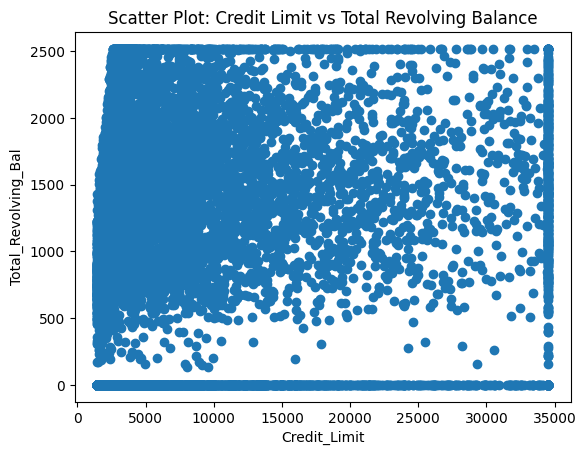

In [5]:
# Testing for visible outliers by scatter plot
plt.scatter(customer_data['Credit_Limit'], customer_data['Total_Revolving_Bal'])
plt.xlabel('Credit_Limit')
plt.ylabel('Total_Revolving_Bal')
plt.title('Scatter Plot: Credit Limit vs Total Revolving Balance')
plt.show()



# Model Building

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # using random_state to get same values on each run

print(len(X_test)) # The x_test (Testing features data) has 3039 rows [30% (approx) of 10127]
print(len(X_train)) # The y_test (Testing features data) has 7088 rows [70% (approx) of 10127]

3039
7088


In [7]:
# Preparing the training and testing datasets
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

c:\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Optimal k: 7
Accuracy with optimal k: 0.87


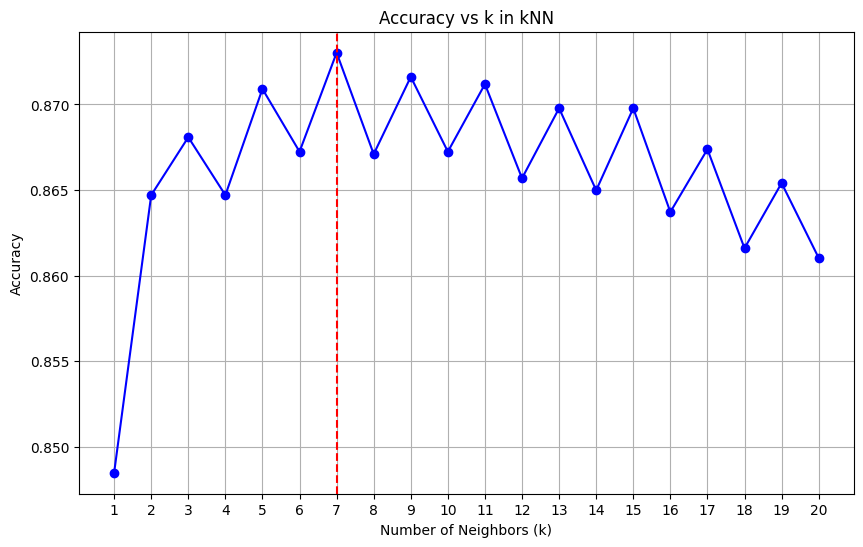

In [8]:
# Hypertuning using grid_search to get the most optimal value of k

# Defining the range of k values to try
param_grid = {'n_neighbors': range(1, 21)}
# Initializing kNN model
knn = KNeighborsClassifier()

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='accuracy')
# Fitting the model on the training data
grid_search.fit(X_train, y_train)
# Storing and Printing the best hyperparameter (k value)
optimal_k = grid_search.best_params_['n_neighbors']
print(f"Optimal k: {optimal_k}")
# Calculating y_pred for the test dataset
y_pred = grid_search.predict(X_test)

# Calculating accuracy for the test dataset
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy with optimal k: {acc:.2f}")
# Plotting the accuracy vs k graph
results = grid_search.cv_results_
mean_accuracies = results['mean_test_score']

plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), mean_accuracies, marker='o', linestyle='-', color='b')
plt.title('Accuracy vs k in kNN')
plt.xlabel('Number of Neighbors (k)')
plt.axvline(optimal_k, color='red', linestyle='--')
plt.ylabel('Accuracy')
plt.xticks(np.arange(1, 21, step=1))
plt.grid()
plt.show()


In [9]:
# Train the model with the optimal k
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

# Testing and Evaluating the model

ROC AUC Score: 0.8164
optimal Threshold: 0.2857
FPR at optimal Threshold: 0.1490
TPR at optimal Threshold: 0.6532


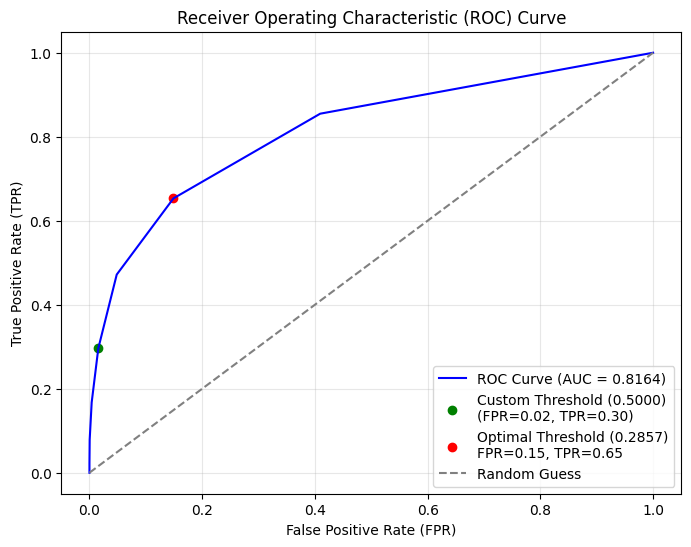

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculating the probabilities for the positive class
y_prob = knn.predict_proba(X_test)[:, 1]

# Calculating ROC AUC score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Calculating ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculating optimal Threshold: Balances sensitivity and specificity (closest to top-left)
# Calculating the distance to the top-left corner
distance_to_corner = np.sqrt((1 - tpr)**2 + fpr**2) 
# Find the index of the minimum distance
optimal_index = np.argmin(distance_to_corner)
optimal_threshold = thresholds[optimal_index]
optimal_fpr = fpr[optimal_index]
optimal_tpr = tpr[optimal_index]
print(f"optimal Threshold: {optimal_threshold:.4f}")
print(f"FPR at optimal Threshold: {optimal_fpr:.4f}")
print(f"TPR at optimal Threshold: {optimal_tpr:.4f}")

# A custom user defined threshold for furthur run-time analysis
custom_threshold = 0.5
closest_index = (abs(thresholds - custom_threshold)).argmin()
fpr_point = fpr[closest_index]
tpr_point = tpr[closest_index]

# Plotting ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", color='blue')
plt.scatter(fpr_point, tpr_point, color='green', 
            label=f"Custom Threshold ({custom_threshold:.4f})\n(FPR={fpr_point:.2f}, TPR={tpr_point:.2f})") # plotting user defined threshold point
plt.scatter(fpr[optimal_index], tpr[optimal_index], color='red', 
            label=f"Optimal Threshold ({optimal_threshold:.4f})\nFPR={fpr[optimal_index]:.2f}, TPR={tpr[optimal_index]:.2f}") # optimal_threshold
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()



In [ ]:
# Evaluating the model on the testing data with default threshold (0.5)
y_pred = knn.predict(X_test)

# Evaluating accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy with default threshold (0.5):", accuracy)
# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8719973675551168
Confusion Matrix:
 [[2503   40]
 [ 349  147]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93      2543
           1       0.79      0.30      0.43       496

    accuracy                           0.87      3039
   macro avg       0.83      0.64      0.68      3039
weighted avg       0.86      0.87      0.85      3039



In [15]:
# Evaluating the model on the training data with default threshold (0.5)
y_pred = knn.predict(X_train)

# Evaluating accuracy
accuracy = accuracy_score(y_train, y_pred)
print("Accuracy with default threshold (0.5):", accuracy)
# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred))
# Classification Report
print("Classification Report:\n", classification_report(y_train, y_pred))

Accuracy with default threshold (0.5): 0.8982787810383747
Confusion Matrix:
 [[5898   59]
 [ 662  469]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94      5957
           1       0.89      0.41      0.57      1131

    accuracy                           0.90      7088
   macro avg       0.89      0.70      0.75      7088
weighted avg       0.90      0.90      0.88      7088



In [13]:
# Evaluating the model on the testing data with optimal threshold (0.28)

# Predict probabilities instead of class labels
y_probs = knn.predict_proba(X_test)
# Setting a custom threshold
threshold = optimal_threshold  # Using the Optimal Threshold obtained from ROC curve
# Applying the threshold to classify
y_pred_custom = (y_probs[:, 1] >= threshold).astype(int)

# Evaluating accuracy with the new threshold
accuracy_custom = accuracy_score(y_test, y_pred_custom)
print(f"Accuracy with custom threshold ({optimal_threshold}):", accuracy_custom)
# Confusion Matrix
print("Confusion Matrix with custom threshold:\n", confusion_matrix(y_test, y_pred_custom))
# Classification Report
print("Classification Report with custom threshold:\n", classification_report(y_test, y_pred_custom))

Accuracy with custom threshold (0.2857142857142857): 0.8186903586706153
Confusion Matrix with custom threshold:
 [[2164  379]
 [ 172  324]]
Classification Report with custom threshold:
               precision    recall  f1-score   support

           0       0.93      0.85      0.89      2543
           1       0.46      0.65      0.54       496

    accuracy                           0.82      3039
   macro avg       0.69      0.75      0.71      3039
weighted avg       0.85      0.82      0.83      3039



In [14]:
# Evaluating the model on the training data with optimal threshold (0.28)

# Predicting and storing probabilities instead of class labels
y_probs = knn.predict_proba(X_train)
# Setting a custom threshold
threshold = optimal_threshold  # Using the Optimal Threshold obtained from ROC curve
# Applying the threshold to classify
y_pred_custom = (y_probs[:, 1] >= threshold).astype(int)

# Evaluating accuracy with the new threshold
accuracy_custom = accuracy_score(y_train, y_pred_custom)
print(f"Accuracy with custom threshold ({optimal_threshold}):", accuracy_custom)
# Confusion Matrix
print("Confusion Matrix with custom threshold:\n", confusion_matrix(y_train, y_pred_custom))
# Classification Report
print("Classification Report with custom threshold:\n", classification_report(y_train, y_pred_custom))


Accuracy with custom threshold (0.2857142857142857): 0.886145598194131
Confusion Matrix with custom threshold:
 [[5320  637]
 [ 170  961]]
Classification Report with custom threshold:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93      5957
           1       0.60      0.85      0.70      1131

    accuracy                           0.89      7088
   macro avg       0.79      0.87      0.82      7088
weighted avg       0.91      0.89      0.89      7088

